In [5]:
import gym
import sys
import pybullet as p

print("gym:", gym.__version__)
print("pybullet build:", p.getAPIVersion())   # эсвэл build time-ийг нь харна

try:
    import pybullet_envs
    print("pybullet_envs: OK")
except Exception as e:
    print("pybullet_envs: FAIL ->", type(e).__name__, e)


gym: 0.20.0
pybullet build: 202010061
pybullet_envs: OK


In [6]:
import os
import glob
import time
from datetime import datetime

import torch
import torch.nn as nn
from torch.distributions import MultivariateNormal, Categorical
import numpy as np
import gym
import pybullet_envs

print("============================================================================================")

device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda:0')
    torch.cuda.empty_cache()
    print("Device set to : " + str(torch.cuda.get_device_name(device)))
else:
    print("Device set to : cpu")

print("============================================================================================")


class RolloutBuffer:
    def __init__(self):
        self.actions = []
        self.states = []
        self.logprobs = []
        self.rewards = []
        self.state_values = []
        self.is_terminals = []

    def clear(self):
        del self.actions[:]
        del self.states[:]
        del self.logprobs[:]
        del self.rewards[:]
        del self.state_values[:]
        del self.is_terminals[:]


class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, has_continuous_action_space, action_std_init):
        super(ActorCritic, self).__init__()

        self.has_continuous_action_space = has_continuous_action_space

        if has_continuous_action_space:
            self.action_dim = action_dim
            self.action_var = torch.full((action_dim,), action_std_init * action_std_init).to(device)

        if has_continuous_action_space:
            self.actor = nn.Sequential(
                nn.Linear(state_dim, 64),
                nn.Tanh(),
                nn.Linear(64, 64),
                nn.Tanh(),
                nn.Linear(64, action_dim),
                nn.Tanh()
            )
        else:
            self.actor = nn.Sequential(
                nn.Linear(state_dim, 64),
                nn.Tanh(),
                nn.Linear(64, 64),
                nn.Tanh(),
                nn.Linear(64, action_dim),
                nn.Softmax(dim=-1)
            )

        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def set_action_std(self, new_action_std):
        if self.has_continuous_action_space:
            self.action_var = torch.full((self.action_dim,), new_action_std * new_action_std).to(device)
        else:
            print("WARNING : Calling ActorCritic::set_action_std() on discrete action space policy")

    def forward(self):
        raise NotImplementedError

    def act(self, state):
        if self.has_continuous_action_space:
            action_mean = self.actor(state)
            cov_mat = torch.diag(self.action_var).unsqueeze(dim=0)
            dist = MultivariateNormal(action_mean, cov_mat)
        else:
            action_probs = self.actor(state)
            dist = Categorical(action_probs)

        action = dist.sample()
        action_logprob = dist.log_prob(action)
        state_val = self.critic(state)

        return action.detach(), action_logprob.detach(), state_val.detach()

    def evaluate(self, state, action):
        if self.has_continuous_action_space:
            action_mean = self.actor(state)
            action_var = self.action_var.expand_as(action_mean)
            cov_mat = torch.diag_embed(action_var).to(device)
            dist = MultivariateNormal(action_mean, cov_mat)

            if self.action_dim == 1:
                action = action.reshape(-1, self.action_dim)
        else:
            action_probs = self.actor(state)
            dist = Categorical(action_probs)

        action_logprobs = dist.log_prob(action)
        dist_entropy = dist.entropy()
        state_values = self.critic(state)

        return action_logprobs, state_values, dist_entropy


class PPO:
    def __init__(self, state_dim, action_dim, lr_actor, lr_critic, gamma, K_epochs,
                 eps_clip, has_continuous_action_space, action_std_init=0.6):

        self.has_continuous_action_space = has_continuous_action_space

        if has_continuous_action_space:
            self.action_std = action_std_init

        self.gamma = gamma
        self.eps_clip = eps_clip
        self.K_epochs = K_epochs

        self.buffer = RolloutBuffer()

        self.policy = ActorCritic(
            state_dim, action_dim, has_continuous_action_space, action_std_init
        ).to(device)

        self.optimizer = torch.optim.Adam([
            {'params': self.policy.actor.parameters(), 'lr': lr_actor},
            {'params': self.policy.critic.parameters(), 'lr': lr_critic}
        ])

        self.policy_old = ActorCritic(
            state_dim, action_dim, has_continuous_action_space, action_std_init
        ).to(device)

        self.policy_old.load_state_dict(self.policy.state_dict())
        self.MseLoss = nn.MSELoss()

    def set_action_std(self, new_action_std):
        if self.has_continuous_action_space:
            self.action_std = new_action_std
            self.policy.set_action_std(new_action_std)
            self.policy_old.set_action_std(new_action_std)
        else:
            print("WARNING : Calling PPO::set_action_std() on discrete action space policy")

    def select_action(self, state):
        with torch.no_grad():
            state = torch.FloatTensor(state).to(device)
            action, action_logprob, state_val = self.policy_old.act(state)

        self.buffer.states.append(state)
        self.buffer.actions.append(action)
        self.buffer.logprobs.append(action_logprob)
        self.buffer.state_values.append(state_val)

        if self.has_continuous_action_space:
            return action.detach().cpu().numpy().flatten()
        else:
            return action.item()

    def update(self):
        rewards = []
        discounted_reward = 0

        for reward, is_terminal in zip(reversed(self.buffer.rewards), reversed(self.buffer.is_terminals)):
            if is_terminal:
                discounted_reward = 0
            discounted_reward = reward + (self.gamma * discounted_reward)
            rewards.insert(0, discounted_reward)

        rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
        rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-7)

        old_states = torch.squeeze(torch.stack(self.buffer.states, dim=0)).detach().to(device)
        old_actions = torch.squeeze(torch.stack(self.buffer.actions, dim=0)).detach().to(device)
        old_logprobs = torch.squeeze(torch.stack(self.buffer.logprobs, dim=0)).detach().to(device)
        old_state_values = torch.squeeze(torch.stack(self.buffer.state_values, dim=0)).detach().to(device)

        advantages = rewards.detach() - old_state_values.detach()

        for _ in range(self.K_epochs):
            logprobs, state_values, dist_entropy = self.policy.evaluate(old_states, old_actions)
            state_values = torch.squeeze(state_values)

            ratios = torch.exp(logprobs - old_logprobs.detach())
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages

            loss = -torch.min(surr1, surr2) + 0.5 * self.MseLoss(state_values, rewards) - 0.01 * dist_entropy

            self.optimizer.zero_grad()
            loss.mean().backward()
            self.optimizer.step()

        self.policy_old.load_state_dict(self.policy.state_dict())
        self.buffer.clear()

    def save(self, checkpoint_path):
        torch.save(self.policy_old.state_dict(), checkpoint_path)

    def load(self, checkpoint_path):
        self.policy_old.load_state_dict(torch.load(checkpoint_path, map_location=lambda storage, loc: storage))
        self.policy.load_state_dict(torch.load(checkpoint_path, map_location=lambda storage, loc: storage))

Device set to : cpu


# PPO Сургалт хийх

In [ ]:
################################### Training ###################################

print("============================================================================================")

env_name = "Combat"
has_continuous_action_space = False

max_ep_len = 400
max_training_timesteps = int(1e5)

print_freq = max_ep_len * 4
log_freq = max_ep_len * 2
save_model_freq = int(2e4)

action_std = None

update_timestep = max_ep_len * 4
K_epochs = 40
eps_clip = 0.2
gamma = 0.99

lr_actor = 0.0003
lr_critic = 0.001

random_seed = 0

print("training environment name : " + env_name)

env = gym.make(
    'ma_gym:Combat-v0',
    grid_shape=(20,20),
    n_agents=5,
    n_opponents=5,
    init_health=10,
    full_observable=False,
    step_cost=0,
    max_steps=100,
    step_cool=1
)

state_dim = env.observation_space[0].shape[0]
action_dim = env.action_space[0].n

###################### logging ######################

log_dir = "PPO_logs/" + env_name + "/"
os.makedirs(log_dir, exist_ok=True)

run_num = len(next(os.walk(log_dir))[2])
log_f_name = log_dir + "PPO_" + env_name + "_log_" + str(run_num) + ".csv"
print("logging at : " + log_f_name)

################### checkpointing ###################

run_num_pretrained = 0
directory = "PPO_preTrained/" + env_name + "/"
os.makedirs(directory, exist_ok=True)

checkpoint_paths = [
    directory + "PPO_{}_{}_{}_agent{}.pth".format(env_name, random_seed, run_num_pretrained, i)
    for i in range(env.n_agents)
]

print("state space dimension : ", state_dim)
print("action space dimension : ", action_dim)
print("Initializing a discrete action space policy")
print("============================================================================================")


ppo_agents = [
    PPO(
        state_dim, action_dim, lr_actor, lr_critic, gamma, K_epochs, eps_clip,
        has_continuous_action_space, action_std
    )
    for _ in range(env.n_agents)
]

start_time = datetime.now().replace(microsecond=0)
print("Started training at (GMT) : ", start_time)
print("============================================================================================")

log_f = open(log_f_name, "w+")
log_f.write('episode,timestep,reward\n')

print_running_reward = 0
print_running_episodes = 0
log_running_reward = 0
log_running_episodes = 0

time_step = 0
i_episode = 0

while time_step <= max_training_timesteps:

    state = env.reset()
    current_ep_reward = 0

    for t in range(1, max_ep_len + 1):

        # Each agent independently selects its own action
        actions = [ppo_agents[i].select_action(state[i]) for i in range(env.n_agents)]

        state, reward, done_n, _ = env.step(actions)

        # Each agent stores its own reward and terminal flag
        for i in range(env.n_agents):
            ppo_agents[i].buffer.rewards.append(reward[i])
            ppo_agents[i].buffer.is_terminals.append(done_n[i])

        time_step += 1
        current_ep_reward += sum(reward)

        # Each agent updates its own policy independently
        if time_step % update_timestep == 0:
            for agent in ppo_agents:
                agent.update()

        if time_step % log_freq == 0 and log_running_episodes > 0:
            log_avg_reward = round(log_running_reward / log_running_episodes, 4)
            log_f.write('{},{},{}\n'.format(i_episode, time_step, log_avg_reward))
            log_f.flush()
            log_running_reward = 0
            log_running_episodes = 0

        if time_step % print_freq == 0 and print_running_episodes > 0:
            print_avg_reward = round(print_running_reward / print_running_episodes, 2)
            print("Episode : {} \t\t Timestep : {} \t\t Average Reward : {}".format(
                i_episode, time_step, print_avg_reward
            ))
            print_running_reward = 0
            print_running_episodes = 0

        # Save each agent's checkpoint independently
        if time_step % save_model_freq == 0:
            for i, agent in enumerate(ppo_agents):
                print("saving agent {} model at : ".format(i) + checkpoint_paths[i])
                agent.save(checkpoint_paths[i])

            print("Elapsed Time : ", datetime.now().replace(microsecond=0) - start_time)

        if all(done_n):
            break

    print_running_reward += current_ep_reward
    print_running_episodes += 1
    log_running_reward += current_ep_reward
    log_running_episodes += 1
    i_episode += 1

log_f.close()
env.close()

print("============================================================================================")
end_time = datetime.now().replace(microsecond=0)
print("Started training at (GMT) : ", start_time)
print("Finished training at (GMT) : ", end_time)
print("Total training time  : ", end_time - start_time)
print("============================================================================================")

training environment name : Combat
logging at : PPO_logs/Combat/PPO_Combat_log_3.csv
state space dimension :  150
action space dimension :  10
Initializing a discrete action space policy
Started training at (GMT) :  2026-03-26 15:23:35
Episode : 18 		 Timestep : 1600 		 Average Reward : -25.72
Episode : 37 		 Timestep : 3200 		 Average Reward : -28.21
Episode : 60 		 Timestep : 4800 		 Average Reward : -33.61
Episode : 81 		 Timestep : 6400 		 Average Reward : -28.48
Episode : 103 		 Timestep : 8000 		 Average Reward : -31.41
Episode : 122 		 Timestep : 9600 		 Average Reward : -25.53
Episode : 140 		 Timestep : 11200 		 Average Reward : -25.33
Episode : 159 		 Timestep : 12800 		 Average Reward : -35.32
Episode : 177 		 Timestep : 14400 		 Average Reward : -30.94
Episode : 196 		 Timestep : 16000 		 Average Reward : -27.58
Episode : 215 		 Timestep : 17600 		 Average Reward : -32.58
Episode : 236 		 Timestep : 19200 		 Average Reward : -25.9
saving agent 0 model at : PPO_preTrained/Co

In [ ]:
#################################### Testing ###################################

print("============================================================================================")

env_name = "Combat"
has_continuous_action_space = False
max_ep_len = 400
action_std = None

total_test_episodes = 10

K_epochs = 80
eps_clip = 0.2
gamma = 0.99
lr_actor = 0.0003
lr_critic = 0.001

env = gym.make(
    'ma_gym:Combat-v0',
    grid_shape=(20,20),
    n_agents=5,
    n_opponents=5,
    init_health=10,
    full_observable=False,
    step_cost=0,
    max_steps=100,
    step_cool=1
)

state_dim = env.observation_space[0].shape[0]

if has_continuous_action_space:
    action_dim = env.action_space[0].shape[0]
else:
    action_dim = env.action_space[0].n


ppo_agents = [
    PPO(
        state_dim, action_dim, lr_actor, lr_critic, gamma, K_epochs, eps_clip,
        has_continuous_action_space, action_std
    )
    for _ in range(env.n_agents)
]


random_seed = 0
run_num_pretrained = 0
directory = "PPO_preTrained/" + env_name + "/"

for i, agent in enumerate(ppo_agents):
    checkpoint_path = directory + "PPO_{}_{}_{}_agent{}.pth".format(
        env_name, random_seed, run_num_pretrained, i
    )
    print("loading network from : " + checkpoint_path)
    agent.load(checkpoint_path)

print("--------------------------------------------------------------------------------------------")

test_running_reward = 0

for ep in range(1, total_test_episodes + 1):

    ep_reward = 0
    state = env.reset()

    for t in range(1, max_ep_len + 1):

    
        actions = [ppo_agents[i].select_action(state[i]) for i in range(env.n_agents)]

        state, reward, done_n, _ = env.step(actions)
        ep_reward += sum(reward)

        if all(done_n):
            break

    for agent in ppo_agents:
        agent.buffer.clear()

    test_running_reward += ep_reward
    print('Episode: {} \t\t Reward: {}'.format(ep, round(ep_reward, 2)))

env.close()

print("============================================================================================")
avg_test_reward = round(test_running_reward / total_test_episodes, 2)
print("average test reward : " + str(avg_test_reward))
print("============================================================================================")

loading network from : PPO_preTrained/Combat/PPO_Combat_0_0_agent0.pth
loading network from : PPO_preTrained/Combat/PPO_Combat_0_0_agent1.pth
loading network from : PPO_preTrained/Combat/PPO_Combat_0_0_agent2.pth
loading network from : PPO_preTrained/Combat/PPO_Combat_0_0_agent3.pth
loading network from : PPO_preTrained/Combat/PPO_Combat_0_0_agent4.pth
--------------------------------------------------------------------------------------------
Episode: 1 		 Reward: -16
Episode: 2 		 Reward: -18
Episode: 3 		 Reward: -22
Episode: 4 		 Reward: -10
Episode: 5 		 Reward: -31
Episode: 6 		 Reward: -29
Episode: 7 		 Reward: -13
Episode: 8 		 Reward: -20
Episode: 9 		 Reward: -8
Episode: 10 		 Reward: -15
average test reward : -18.2


total number of frames / timesteps / images saved :  47
average test reward : -42.0


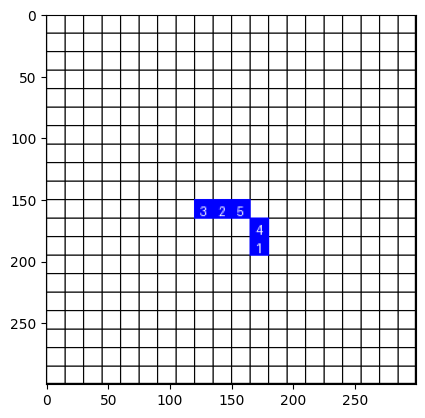

In [11]:
############################# save images for gif ##############################

import os
import glob
import gym
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display

display = Display(visible=0, size=(400, 300))
display.start()

print("============================================================================================")

env_name = "Combat"
has_continuous_action_space = False
max_ep_len = 400
action_std = None

total_test_episodes = 1     # gif хийхэд 1 episode хангалттай
render_ipython = True       # notebook дээр frame харуулах эсэх

K_epochs = 80
eps_clip = 0.2
gamma = 0.99
lr_actor = 0.0003
lr_critic = 0.001

env = gym.make(
    'ma_gym:Combat-v0',
    grid_shape=(20,20),
    n_agents=5,
    n_opponents=5,
    init_health=10,
    full_observable=False,
    step_cost=0,
    max_steps=100,
    step_cool=1
)

state_dim = env.observation_space[0].shape[0]

if has_continuous_action_space:
    action_dim = env.action_space[0].shape[0]
else:
    action_dim = env.action_space[0].n

# make directory for saving gif images
gif_images_dir = "PPO_gif_images/" + env_name + "/"
os.makedirs(gif_images_dir, exist_ok=True)

# make directory for gif
gif_dir = "PPO_gifs/" + env_name + "/"
os.makedirs(gif_dir, exist_ok=True)

# One independent PPO agent per environment agent
ppo_agents = [
    PPO(
        state_dim, action_dim, lr_actor, lr_critic, gamma, K_epochs, eps_clip,
        has_continuous_action_space, action_std
    )
    for _ in range(env.n_agents)
]

# Load each agent's own pretrained weights
random_seed = 0
run_num_pretrained = 0
directory = "PPO_preTrained/" + env_name + "/"

for i, agent in enumerate(ppo_agents):
    checkpoint_path = directory + "PPO_{}_{}_{}_agent{}.pth".format(
        env_name, random_seed, run_num_pretrained, i
    )
    print("loading network from : " + checkpoint_path)
    agent.load(checkpoint_path)

print("--------------------------------------------------------------------------------------------")

test_running_reward = 0

for ep in range(1, total_test_episodes + 1):

    ep_reward = 0
    state = env.reset()

    for t in range(1, max_ep_len + 1):

        actions = [ppo_agents[i].select_action(state[i]) for i in range(env.n_agents)]
        state, reward, done_n, _ = env.step(actions)

        ep_reward += sum(reward)

        img = env.render(mode='rgb_array')

        if render_ipython:
            plt.imshow(img)
            ipythondisplay.clear_output(wait=True)
            ipythondisplay.display(plt.gcf())

        img = Image.fromarray(img)
        img.save(gif_images_dir + str(t).zfill(6) + '.jpg')

        if all(done_n):
            break

    for agent in ppo_agents:
        agent.buffer.clear()

    test_running_reward += ep_reward
    print('Episode: {} \t\t Reward: {}'.format(ep, round(ep_reward, 2)))

env.close()

if render_ipython:
    ipythondisplay.clear_output(wait=True)

print("============================================================================================")
print("total number of frames / timesteps / images saved : ", t)

avg_test_reward = round(test_running_reward / total_test_episodes, 2)
print("average test reward : " + str(avg_test_reward))
print("============================================================================================")

In [12]:
######################## generate gif from saved images ########################

import os
import glob
from PIL import Image

print("============================================================================================")

env_name = 'Combat'
gif_num = 0

# gif-ийн чанар / хугацааны тохиргоо
total_timesteps = 300
step = 10
frame_duration = 150   # milliseconds

# input images
gif_images_pattern = "PPO_gif_images/" + env_name + "/*.jpg"

# output gif path
gif_dir = "PPO_gifs/" + env_name
os.makedirs(gif_dir, exist_ok=True)

gif_path = gif_dir + '/PPO_' + env_name + '_gif_' + str(gif_num) + '.gif'

img_paths = sorted(glob.glob(gif_images_pattern))
img_paths = img_paths[:total_timesteps]
img_paths = img_paths[::step]

print("total frames in gif : ", len(img_paths))
print("total duration of gif : " + str(round(len(img_paths) * frame_duration / 1000, 2)) + " seconds")

img, *imgs = [Image.open(f) for f in img_paths]
img.save(
    fp=gif_path,
    format='GIF',
    append_images=imgs,
    save_all=True,
    optimize=True,
    duration=frame_duration,
    loop=0
)

print("saved gif at : ", gif_path)
print("============================================================================================")

total frames in gif :  10
total duration of gif : 1.5 seconds
saved gif at :  PPO_gifs/Combat/PPO_Combat_gif_0.gif
